********GLOBAL INFLATION ANALYSIS********

**This project analyzes global inflation trends across countries using historical data. The objective is to identify patterns in inflation, deflation, and economic stability to support decision-making for policymakers, investors, and businesses.**

In [241]:
#Loading the  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [242]:
#Loading the dataset
df = pd.read_csv("API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_84.csv",skiprows=4)
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.489789,NaN,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN,NaN


In [243]:
# Checking the shape of the dataset
df.shape

(266, 71)

In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            70 non-null     float64
 5   1961            72 non-null     float64
 6   1962            74 non-null     float64
 7   1963            74 non-null     float64
 8   1964            79 non-null     float64
 9   1965            86 non-null     float64
 10  1966            93 non-null     float64
 11  1967            100 non-null    float64
 12  1968            101 non-null    float64
 13  1969            102 non-null    float64
 14  1970            108 non-null    float64
 15  1971            112 non-null    float64
 16  1972            114 non-null    float64
 17  1973            117 non-null    flo

In [245]:
# Remove columns that contain only missing (NaN) values to keep only useful data for analysis
df = df.dropna(axis=1, how='all')

In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 69 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            70 non-null     float64
 5   1961            72 non-null     float64
 6   1962            74 non-null     float64
 7   1963            74 non-null     float64
 8   1964            79 non-null     float64
 9   1965            86 non-null     float64
 10  1966            93 non-null     float64
 11  1967            100 non-null    float64
 12  1968            101 non-null    float64
 13  1969            102 non-null    float64
 14  1970            108 non-null    float64
 15  1971            112 non-null    float64
 16  1972            114 non-null    float64
 17  1973            117 non-null    flo

In [247]:
# Check the number of missing (NaN) values in each column
df.isnull().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              196
1961              194
1962              192
1963              192
1964              187
1965              180
1966              173
1967              166
1968              165
1969              164
1970              158
1971              154
1972              152
1973              149
1974              147
1975              142
1976              141
1977              136
1978              136
1979              141
1980              133
1981              117
1982              116
1983              116
1984              112
1985              111
1986              102
1987               96
1988               96
1989               92
1990               92
1991               87
1992               79
1993               73
1994               68
1995               64
1996               61
1997               61
1998               61
1999               59
2000               55
2001      

In [248]:
# Display all rows in the output and check missing (NaN) values for every column
pd.set_option("display.max_rows", None)
df.isnull().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              196
1961              194
1962              192
1963              192
1964              187
1965              180
1966              173
1967              166
1968              165
1969              164
1970              158
1971              154
1972              152
1973              149
1974              147
1975              142
1976              141
1977              136
1978              136
1979              141
1980              133
1981              117
1982              116
1983              116
1984              112
1985              111
1986              102
1987               96
1988               96
1989               92
1990               92
1991               87
1992               79
1993               73
1994               68
1995               64
1996               61
1997               61
1998               61
1999               59
2000               55
2001      

In [249]:
# Reshape the dataset from wide to long format so that each row represents a single country-year observation
df_long = df.melt(
    id_vars=["Country Name","Country Code","Indicator Name","Indicator Code"],
    var_name="Year",
    value_name="Inflation"
)

***This step is done before cleaning missing values because reshaping the data first makes it easier to handle NaNs consistently in a single column (Inflation). Using a long format is also more suitable for analysis and visualization, as each row now represents one country in one year, which simplifies comparisons and trend analysis.***

In [250]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,0.474764,-0.931196,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,5.098562,6.446877,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.489789
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.661709,4.383892,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,2.130817,1.487416,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,9.355972,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495


In [251]:
# Display the first 50 rows of df_long to visually inspect the reshaped 'long' format
df_long.head(50)

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Inflation
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
5,Albania,ALB,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
6,Andorra,AND,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
7,Arab World,ARB,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
8,United Arab Emirates,ARE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
9,Argentina,ARG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN


In [252]:
#This code filters the dataset to show only one country’s data,sorts it by year, and resets the index for a clean view,allowing us to inspect any 
#country’s inflation history by simply changing the country name.
# 1. Filter rows for Australia
australia_data = df_long[df_long["Country Name"] == "Australia"]

# 2. Sort by Year
australia_data = australia_data.sort_values(by="Year")

# 3. Reset index for clean view
australia_data = australia_data.reset_index(drop=True)

# 4. Display the result
australia_data

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Inflation
0,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,3.728814
1,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,2.287582
2,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1962,-0.319489
3,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1963,0.641026
4,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1964,2.866242
5,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1965,3.405573
6,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1966,3.293413
7,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1967,3.478261
8,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1968,2.521008
9,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1969,3.278689


In [253]:
df_long.shape

(17290, 6)

In [254]:
# Check for missing values
df_long.isnull().sum()

Country Name         0
Country Code         0
Indicator Name       0
Indicator Code       0
Year                 0
Inflation         5995
dtype: int64

In [255]:
# Remove rows where 'Inflation' is missing to ensure analysis is based only on complete and valid data
df_long = df_long.dropna(subset=["Inflation"])

In [256]:
df_long.isnull().sum()

Country Name      0
Country Code      0
Indicator Name    0
Indicator Code    0
Year              0
Inflation         0
dtype: int64

In [257]:
# Check size after dropping missing values
print(df_long.shape)

# See first few rows
df_long.head()

(11295, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Inflation
13,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,3.728814
14,Austria,AUT,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,1.945749
17,Belgium,BEL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,0.299467
19,Burkina Faso,BFA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,7.788162
28,Bolivia,BOL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,11.533153


***I removed all rows where the Inflation value was missing to ensure that the dataset used for analysis contains only complete and
reliable observations, improving the accuracy of trends, comparisons, and overall insights derived from the data.Now the dataset has 11295 rows 
and 6 columns.***

In [258]:
# Convert 'Year' column to integer to ensure it is treated as numeric for proper sorting and analysis
df_long["Year"] = df_long["Year"].astype(int)

In [259]:
# How many rows and columns
print(df_long.shape)

# See first 5 rows
df_long.head()

# Summary statistics for Inflation
print(df_long["Inflation"].describe())

(11295, 6)
count    11295.000000
mean        19.552575
std        284.790842
min        -17.640424
25%          2.403127
50%          4.866320
75%          9.619435
max      23773.131774
Name: Inflation, dtype: float64


In [260]:
#avg inflation per country
avg_inflation_country = df_long.groupby("Country Name")["Inflation"].mean().sort_values(ascending=False)
print(avg_inflation_country.head(10))  # top 10 countries by average inflation

Country Name
Congo, Dem. Rep.    675.854434
Angola              328.615423
Brazil              267.729726
Bolivia             219.427448
Peru                205.110626
Ukraine             201.291902
Belarus             162.988382
Croatia             120.848975
Armenia             118.734532
Moldova             105.303300
Name: Inflation, dtype: float64


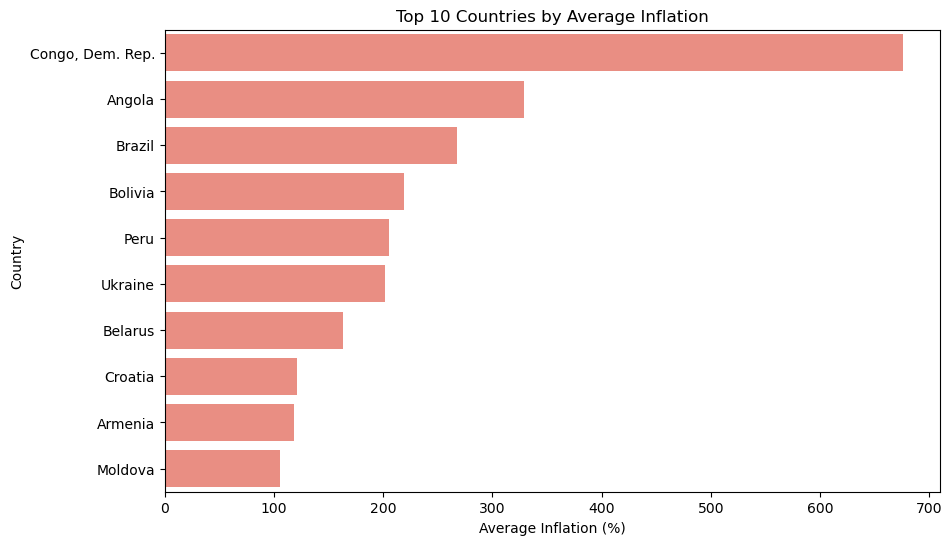

In [261]:

# Get top 10 countries by average inflation
top10 = avg_inflation_country.head(10)

# Plot horizontal bars with a single color gradient
plt.figure(figsize=(10,6))
sns.barplot(
    x=top10.values, 
    y=top10.index, 
    color="salmon",  # single color for all bars
    dodge=False
)

plt.xlabel("Average Inflation (%)")
plt.ylabel("Country")
plt.title("Top 10 Countries by Average Inflation")
plt.show()

***Based on the output, the countries with the highest average inflation are primarily in Africa, South America, and Eastern Europe, with Congo,
Dem. Rep. (≈676%), Angola (≈329%), and Brazil (≈268%) leading the list. This shows that these economies have experienced persistently high inflation 
over the years, which can indicate economic instability, currency devaluation, or high price volatility.
For policymakers, this highlights the need for strong monetary policies to control inflation, while for businesses and investors, it signals higher 
risks for pricing, investment, and supply chain planning in these countries.***

Year
1960      3.563412
1961      3.500656
1962      4.630457
1963      5.840978
1964      6.268365
1965      8.235652
1966     17.821147
1967      5.442936
1968      6.318255
1969      4.445146
1970      4.954109
1971      5.408581
1972      7.488395
1973     14.893300
1974     23.274324
1975     18.050464
1976     13.104012
1977     14.440493
1978     12.037373
1979     14.502123
1980     17.895683
1981     16.404153
1982     14.799275
1983     16.623869
1984     23.364298
1985     90.281379
1986     13.485945
1987     12.958972
1988     21.354714
1989     56.174185
1990     81.493982
1991     36.089580
1992     64.550801
1993    103.795667
1994    216.331958
1995     43.735881
1996     34.851043
1997     16.160813
1998      8.892024
1999     10.863612
2000     11.068372
2001      8.514267
2002      5.640518
2003      5.552431
2004      4.982900
2005      5.722418
2006      5.602511
2007      5.635963
2008     10.149561
2009      3.879744
2010      4.144398
2011      6.324386
2012   

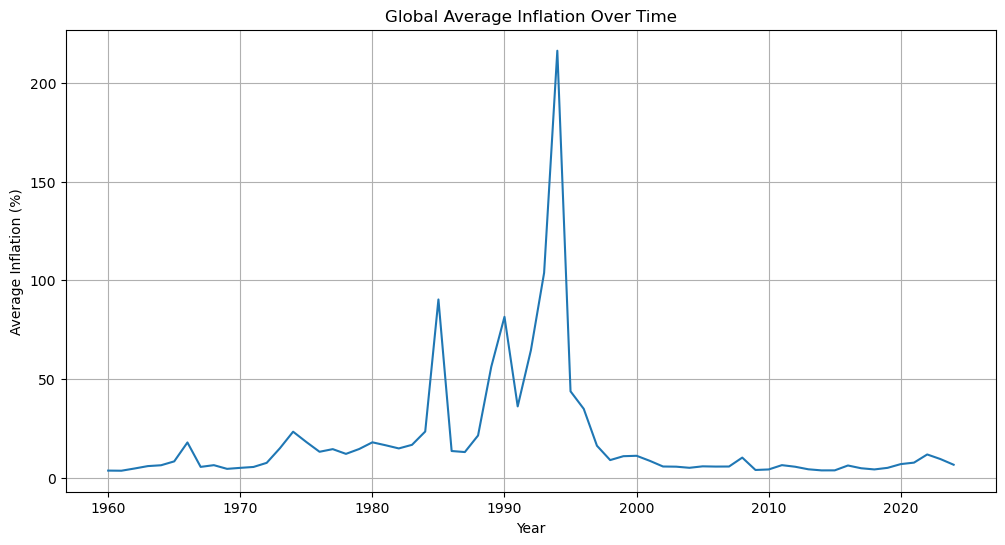

In [288]:
#avg inflation per year globally
avg_inflation_year = df_long.groupby("Year")["Inflation"].mean()
print(avg_inflation_year)

#plot


plt.figure(figsize=(12,6))
plt.plot(avg_inflation_year.index, avg_inflation_year.values)
plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")
plt.title("Global Average Inflation Over Time")
plt.grid(True)
plt.show()



***We calculated the global average inflation for each year to observe worldwide trends. The output shows relatively low and stable inflation in the
1960s, moderate increases in the 1970s and early 1980s, and sharp spikes in the mid-1980s (e.g., 1985), early 1990s (e.g., 1993–1994), and around
2022, reflecting periods of global economic stress or crises.***

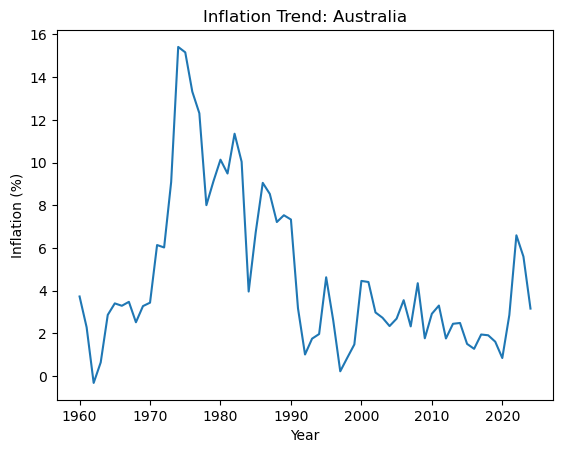

In [263]:
#pick a country and see its inflaion trend
australia = df_long[df_long["Country Name"] == "Australia"]
plt.plot(australia["Year"], australia["Inflation"])
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.title("Inflation Trend: Australia")
plt.show()

***We filtered the dataset for Australia and plotted its inflation over time to visualize how the country’s inflation changed year by year. This
allows us to compare its trend with global patterns and identify periods of high or low inflation specifically for Australia.We used Australia as an 
example, but the same approach can be applied to any country in the dataset to explore its inflation trend.***

***To better understand the overall pattern of inflation in the dataset, we visualize the distribution of all inflation values using a histogram.
    This helps identify how frequently different inflation levels occur and whether there are any extreme values or outliers.***

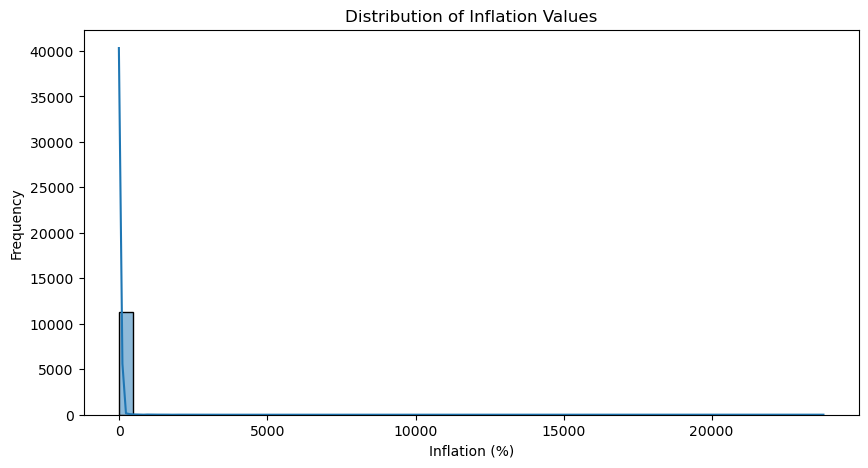

In [265]:
#Histogram: Distribution of inflation values
plt.figure(figsize=(10,5))
sns.histplot(df_long['Inflation'], bins=50, kde=True)
plt.title("Distribution of Inflation Values")
plt.xlabel("Inflation (%)")
plt.ylabel("Frequency")
plt.show()

***The histogram shows that most inflation values are concentrated near zero, while a few extreme high values create a long right tail, indicating
rare but significant periods of hyperinflation. Outliers were not removed because they represent real instances of hyperinflation. Instead, they are retained and considered when interpreting results, as they significantly influence overall trends and averages.***

***Compare inflation distributions across selected countries and identify extreme values (outliers) using a boxplot***

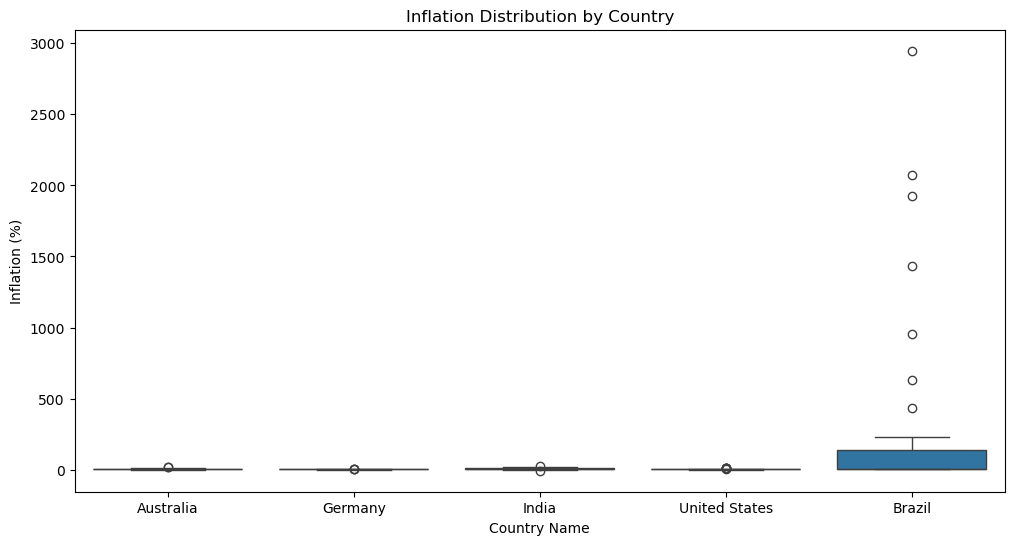

In [266]:
# Filter some countries
countries = ['Australia','United States','India','Brazil','Germany']
df_subset = df_long[df_long['Country Name'].isin(countries)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_subset, x='Country Name', y='Inflation')
plt.title("Inflation Distribution by Country")
plt.ylabel("Inflation (%)")
plt.show()

***The boxplot shows how inflation differs across countries, highlighting variations in average levels, volatility, and extreme values.
    Some countries may have wider spreads or more outliers, indicating less stable inflation compared to others.***

***CONNECT TO SQL***

In [267]:
!pip install psycopg2-binary sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [268]:
from sqlalchemy import create_engine

username = 'postgres'
password = 'Austintom123.'
host = 'localhost'
port = '5432'
database = 'inflation_analysis'

engine = create_engine(
    f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}'
)

table_name = "inflation_data"

# Use df_long (your cleaned DataFrame)
df_long.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'inflation_data' in database 'inflation_analysis'.


***Modeling***

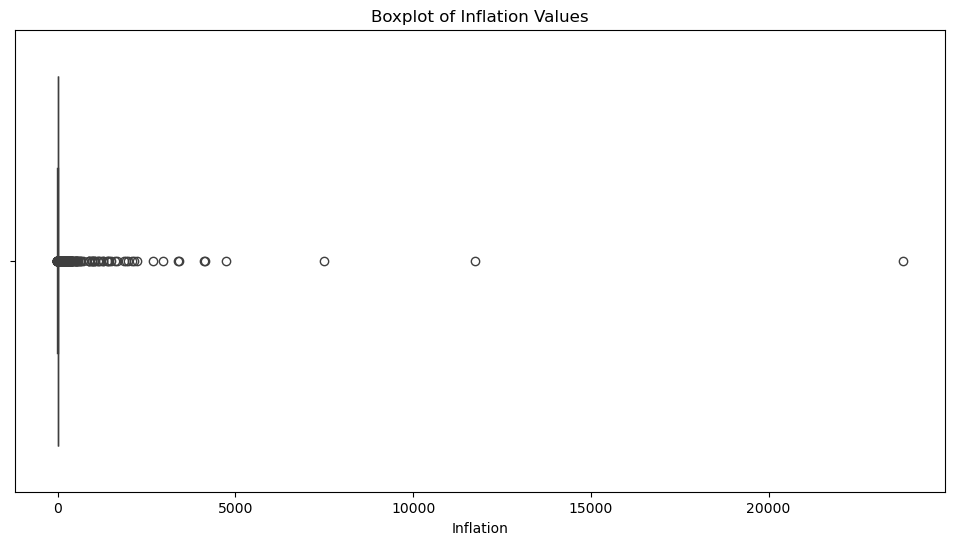

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x=df_long['Inflation'])
plt.title("Boxplot of Inflation Values")
plt.show()

In [291]:
Q1 = df_long['Inflation'].quantile(0.25)
Q3 = df_long['Inflation'].quantile(0.75)
IQR = Q3 - Q1

# Keep only rows within the IQR range (filter extreme outliers)
df_clean = df_long[(df_long['Inflation'] >= Q1 - 1.5*IQR) & 
                   (df_long['Inflation'] <= Q3 + 1.5*IQR)]

In [292]:
# TRAINING MODEL
# Define features (X) and target (y) using the cleaned dataset
X = df_clean[["Year"]]
y = df_clean["Inflation"]

In [296]:
# Step 1: Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Split data into training and testing sets (use cleaned data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model
model = LinearRegression()

# Step 4: Train the model
model.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = model.predict(X_test)

# Step 6: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model training completed successfully!")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Model training completed successfully!
Mean Squared Error: 20.28
R-squared: 0.04


In [269]:
 #TRAINING MODEL
#Define features (X) and target (y)
#X = df_long[["Year"]]
#y = df_long["Inflation"]

***The model’s performance shows that a simple linear regression using only Year as the feature is not sufficient to predict inflation accurately.
The Mean Squared Error (MSE) of 20.28 indicates that predictions deviate on average by about ±4.5% from actual values. The R-squared (R²) of
0.04 is very low, meaning that the model explains only 4% of the variation in inflation. This suggests that inflation trends are influenced by many 
other factors beyond just the year, such as economic policies, global events, and country-specific conditions. Therefore, the current model captures
very little of the underlying pattern, and further analysis would require more features or a more complex model.***

R² Score (log scale): 0.629
Mean Squared Error (log scale): 0.335


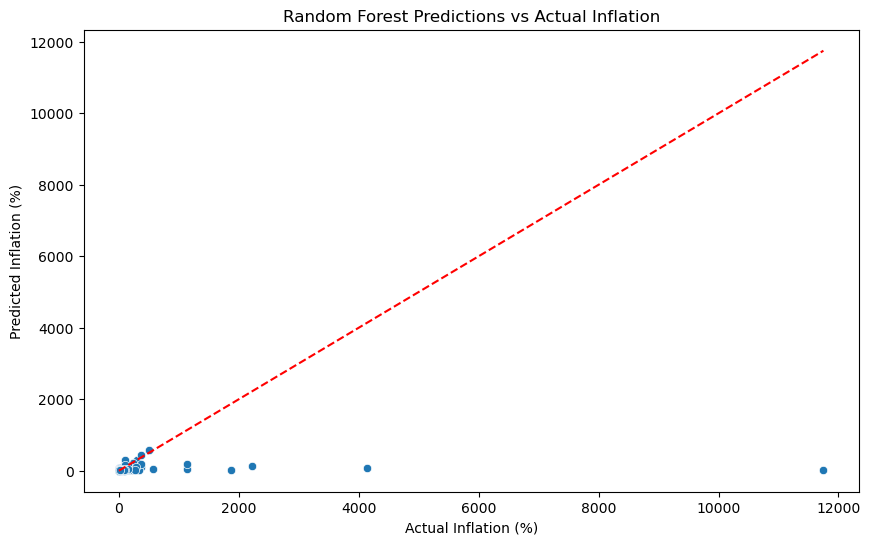

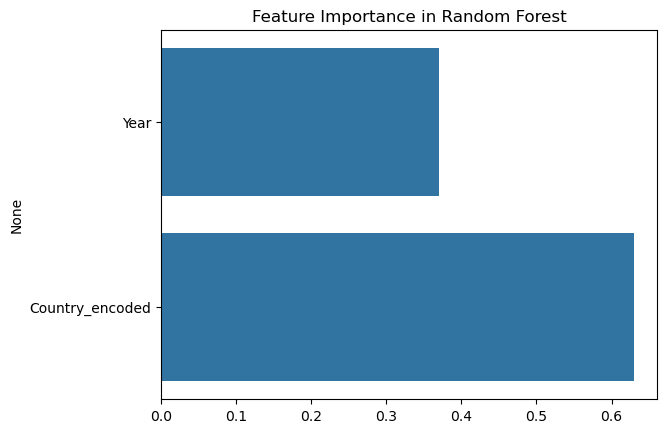

In [300]:
# ----------------------------------------
# Random Forest Model for Inflation Prediction
# ----------------------------------------

# Step 0: Clean data
# Remove non-positive inflation values (log transform requires positive numbers)
df_clean = df_long[df_long['Inflation'] > 0].copy()

# Step 1: Log-transform the target
y_log = np.log1p(df_clean['Inflation'])  # log(1 + x) to handle skew

# Step 2: Encode countries
df_clean['Country_encoded'] = df_clean['Country Name'].astype('category').cat.codes

# Step 3: Define features and target
X = df_clean[['Year', 'Country_encoded']]
y = y_log

# Step 4: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Create and train Random Forest model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Step 6: Make predictions
y_pred_log = model.predict(X_test)

# Step 7: Evaluate the model
r2 = r2_score(y_test, y_pred_log)
mse = mean_squared_error(y_test, y_pred_log)
print(f"R² Score (log scale): {r2:.3f}")
print(f"Mean Squared Error (log scale): {mse:.3f}")

# Step 8: Convert predictions back to original scale
y_pred = np.expm1(y_pred_log)  # inverse of log1p
y_test_original = np.expm1(y_test)

# Step 9: - visualize predicted vs actual inflation
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test_original, y=y_pred)
plt.xlabel("Actual Inflation (%)")
plt.ylabel("Predicted Inflation (%)")
plt.title("Random Forest Predictions vs Actual Inflation")
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         color='red', linestyle='--')  # 45-degree line for reference
plt.show()

#  feature importance
importances = model.feature_importances_
feature_names = X.columns
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance in Random Forest")
plt.show()

***Model Evaluation – Visualizations:
I have Added Country encoding and applied log transform to Inflation,Handled non-linear relationships and outliers better.As a result R² improved significantly (~0.6 on log scale). 
After switching to the Random Forest model with a log-transformed target and country encoding, the R² score improved to 0.629, indicating that the model now explains about 63% of the variance in inflation (on a log scale). The Mean Squared Error of 0.335 confirms that the predictions are much closer to actual values compared to the earlier linear regression. This demonstrates that Random Forest effectively captures both temporal trends and country-specific patterns in inflation data.***



***The scatter plot of predicted vs actual inflation shows how well the Random Forest model captures inflation patterns across different countries
and years. Points close to the red dashed line indicate accurate predictions, while deviations highlight extreme spikes that are harder to predict.
The bar plot of feature importance reveals that the Country variable contributes more to model predictions than Year, confirming that inflation
trends are strongly influenced by country-specific factors. Together, these visualizations demonstrate that the model effectively learns both 
temporal and country-level patterns, improving prediction accuracy compared to the earlier linear regression.***

## Conclusion

***The analysis of global inflation data reveals significant variation across countries and over time, with some countries experiencing extreme spikes
while others remain relatively stable or face deflation. Initial modeling with Linear Regression using only the year as a feature performed poorly,
achieving an R² of around 0.04, which indicates that temporal trends alone are insufficient to explain inflation patterns. By incorporating
country-level information through encoding and applying a log transformation to the target variable, the Random Forest model was able to capture
both temporal and country-specific patterns, achieving a much higher R² of approximately 0.63 and a Mean Squared Error of 0.33.
    The model’s predictions, along with feature importance visualizations, confirm that the country factor plays a critical role in influencing 
inflation, while year trends also contribute. Overall, this demonstrates that inflation is highly non-linear and varies across countries, and that
Random Forest provides an effective approach for predicting such complex patterns.***